In [8]:
!pip install numpy_financial
!pip install xlsxwriter
# ==============================================================================
# 1. SCRIPT SETUP AND LIBRARY IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Define global constants and file paths
INPUT_FILE = 'group3_sensitivity_analysis.xlsx'
OUTPUT_FILE = 'Financial_Model_and_Sensitivity_Analysis.xlsx'
PERPETUAL_GROWTH_RATE = 0.025
ASSET_USEFUL_LIFE = 10

# New Section

In [9]:
# ==============================================================================
# 2. DATA INGESTION FUNCTION
# ==============================================================================
def load_base_assumptions(file_path):
    """
    Loads base case assumptions from the specified Excel file.

    Args:
        file_path (str): The path to the input Excel file.

    Returns:
        dict: A dictionary containing pandas Series for each input variable.
    """
    try:
        df = pd.read_excel(file_path, sheet_name='Base Values', index_col='Description')

        # Drop the 'Calculation' column and select only the year columns
        df_values = df.drop(columns=['Calculation'])

        assumptions = {
            'price_per_unit': df_values.loc['Price per Unit(₹)'].values[:-2], # Exclude last two columns
            'sales_volume': df_values.loc['Sales Volume / Quantity Sold (# in Crore)'].values[:-2], # Exclude last two columns
            'var_cost': df_values.loc['Production Variable Cost (₹ Cr)'].values[:-2], # Exclude last two columns
            'fix_cost': df_values.loc['Production Fixed Cost (₹ Cr)'].values[:-2], # Exclude last two columns
            'opex': df_values.loc['Operating Expenses {OPEX}(₹ Cr)'].values[:-2], # Exclude last two columns
            'tax_rate': df_values.loc['Tax Rate (%)'].values[:-2] / 100, # Exclude last two columns and Convert to decimal
            'dso': df_values.loc['Receivable Days{DSO} (No. of Days)'].values[:-2], # Exclude last two columns
            'dio': df_values.loc['Inventory Days{DIO} (No. of Days)'].values[:-2], # Exclude last two columns
            'dpo': df_values.loc['Payable Days{DPO} (No. of Days)'].values[:-2], # Exclude last two columns
            'capex': df_values.loc['Capital Expenditure {CAPEX} (₹ Cr)'].values[:-2], # Exclude last two columns
            'wacc': df_values.loc['WACC (%)'].values[0] / 100 # WACC is a single value, convert to decimal
        }
        return assumptions
    except FileNotFoundError:
        print(f"Error: Input file not found at {file_path}")
        return None
    except KeyError as e:
        print(f"Error: A required line item was not found in the Excel file: {e}")
        return None

In [10]:
# ==============================================================================
# 3. CORE FINANCIAL MODEL AND VALUATION FUNCTION
# ==============================================================================
def calculate_npv_irr(assumptions):
    """
    Builds a full pro-forma DCF model and calculates NPV and IRR.
    Removes the perpetuity calculation and column.

    Args:
        assumptions (dict): A dictionary of input assumptions.

    Returns:
        tuple: A tuple containing the final NPV, a list of IRRs, and the pro-forma DataFrame.
    """
    num_years = len(assumptions['price_per_unit'])
    years = range(0, num_years)

    # Initialize a DataFrame to store the pro-forma model, excluding Perpetuity
    model = pd.DataFrame(index=['Revenue', 'COGS', 'OPEX', 'EBIT', 'Depreciation', 'EBITDA', 'NOPAT', 'Operating Cash Flow', 'Accounts Receivable', 'Inventory', 'Accounts Payable', 'Net Working Capital', 'Change in NWC', 'CAPEX', 'FCFF', 'Discount Factor', 'Discounted FCFF', 'Cumulative NPV'], columns=[f'Year {y}' for y in years], dtype=float).fillna(0)

    # --- Step 1: P&L Calculations ---
    model.loc['Revenue', [f'Year {y}' for y in range(1, num_years)]] = assumptions['price_per_unit'][1:] * assumptions['sales_volume'][1:]
    model.loc['COGS', [f'Year {y}' for y in range(1, num_years)]] = assumptions['var_cost'][1:] + assumptions['fix_cost'][1:]
    model.loc['OPEX', [f'Year {y}' for y in range(1, num_years)]] = assumptions['opex'][1:]
    model.loc['EBIT', [f'Year {y}' for y in range(1, num_years)]] = model.loc['Revenue', [f'Year {y}' for y in range(1, num_years)]] - model.loc['COGS', [f'Year {y}' for y in range(1, num_years)]] - model.loc['OPEX', [f'Year {y}' for y in range(1, num_years)]]

    # --- Step 2: Layered Straight-Line Depreciation ---
    capex_series = assumptions['capex']
    depreciation_schedule = np.zeros((num_years, num_years))
    for i in range(num_years):
        capex_val = capex_series[i]
        if capex_val > 0:
            annual_depreciation = capex_val / ASSET_USEFUL_LIFE
            for j in range(1, ASSET_USEFUL_LIFE + 1):
                if (i + j) < num_years:
                    depreciation_schedule[i + j, i] = annual_depreciation

    model.loc['Depreciation', [f'Year {y}' for y in range(1, num_years)]] = np.sum(depreciation_schedule, axis=1)[1:]


    # --- Step 3: NOPAT and Operating Cash Flow ---
    model.loc['EBITDA', [f'Year {y}' for y in range(1, num_years)]] = model.loc['EBIT', [f'Year {y}' for y in range(1, num_years)]] - model.loc['Depreciation', [f'Year {y}' for y in range(1, num_years)]]
    model.loc['NOPAT', [f'Year {y}' for y in range(1, num_years)]] = model.loc['EBITDA', [f'Year {y}' for y in range(1, num_years)]] * (1 - assumptions['tax_rate'][1:])
    model.loc['Operating Cash Flow', [f'Year {y}' for y in range(1, num_years)]] = model.loc['NOPAT', [f'Year {y}' for y in range(1, num_years)]] + model.loc['Depreciation', [f'Year {y}' for y in range(1, num_years)]]


    # --- Step 4: Net Working Capital (NWC) Schedule ---
    model.loc['Accounts Receivable', [f'Year {y}' for y in range(1, num_years)]] = model.loc['Revenue', [f'Year {y}' for y in range(1, num_years)]] * assumptions['dso'][1:] / 365
    model.loc['Inventory', [f'Year {y}' for y in range(1, num_years)]] = model.loc['COGS', [f'Year {y}' for y in range(1, num_years)]] * assumptions['dio'][1:] / 365
    model.loc['Accounts Payable', [f'Year {y}' for y in range(1, num_years)]] = model.loc['COGS', [f'Year {y}' for y in range(1, num_years)]] * assumptions['dpo'][1:] / 365
    model.loc['Net Working Capital', [f'Year {y}' for y in range(1, num_years)]] = model.loc['Accounts Receivable', [f'Year {y}' for y in range(1, num_years)]] + model.loc['Inventory', [f'Year {y}' for y in range(1, num_years)]] - model.loc['Accounts Payable', [f'Year {y}' for y in range(1, num_years)]]

    nwc_values = model.loc['Net Working Capital'].values
    delta_nwc = np.diff(nwc_values, prepend=0)
    model.loc['Change in NWC'] = delta_nwc


    # --- Step 5: Free Cash Flow to the Firm (FCFF) ---
    model.loc['CAPEX', [f'Year {y}' for y in years]] = assumptions['capex']
    model.loc['FCFF', [f'Year {y}' for y in years]] = model.loc['Operating Cash Flow', [f'Year {y}' for y in years]].values - model.loc['CAPEX', [f'Year {y}' for y in years]].values - model.loc['Change in NWC', [f'Year {y}' for y in years]].values


    # --- Step 6: NPV and IRR Calculation ---
    # Use FCFF stream from Year 0 onwards
    fcff_stream = model.loc['FCFF', [f'Year {y}' for y in years]].tolist()

    # numpy-financial's npv function calculates the sum of discounted cash flows,
    # which matches the project's total NPV including the initial investment at t=0.
    wacc = assumptions['wacc']
    npv = npf.npv(wacc, fcff_stream)

    # Calculate IRRs by finding roots of the NPV polynomial
    # We test a range of discount rates to find where NPV crosses zero
    discount_rates_for_irr = np.linspace(0, 0.5, 501)
    npv_profile = [npf.npv(r, fcff_stream) for r in discount_rates_for_irr]

    # Find where the sign of NPV changes, indicating a root (IRR)
    irr_list = []
    for i in range(len(npv_profile) - 1):
        if np.sign(npv_profile[i])!= np.sign(npv_profile[i+1]):
            # Linear interpolation to find a more precise root
            irr = np.interp(0, [npv_profile[i+1], npv_profile[i]], [discount_rates_for_irr[i+1], discount_rates_for_irr[i]])
            irr_list.append(irr)

    # --- Step 7: Final Formatting for Output ---
    discount_periods = np.arange(num_years)
    model.loc['Discount Factor', [f'Year {y}' for y in years]] = 1 / ((1 + wacc) ** discount_periods)
    model.loc['Discounted FCFF', [f'Year {y}' for y in years]] = model.loc['FCFF', [f'Year {y}' for y in years]] * model.loc['Discount Factor', [f'Year {y}' for y in years]]
    model.loc['Cumulative NPV', [f'Year {y}' for y in years]] = model.loc['Discounted FCFF', [f'Year {y}' for y in years]].cumsum()


    return npv, irr_list, model

In [11]:
# ==============================================================================
# 4. SENSITIVITY ANALYSIS EXECUTION FUNCTION
# ==============================================================================
def run_sensitivity_analysis(base_assumptions):
    """
    Performs a one-variable-at-a-time sensitivity analysis.
    Removes the perpetuity column from sensitivity results.

    Args:
        base_assumptions (dict): The dictionary of base case assumptions.

    Returns:
        dict: A dictionary where keys are variable names and values are
              DataFrames of sensitivity results.
    """
    sensitivity_results = {}
    variables_to_test = {
        'Price per Unit': 'price_per_unit',
        'Sales Volume': 'sales_volume',
        'COGS': ['var_cost', 'fix_cost'], # COGS is a combination of two inputs
        'OPEX': 'opex',
        'Tax Rate': 'tax_rate',
        'DSO': 'dso',
        'DIO': 'dio',
        'DPO': 'dpo',
        'CAPEX': 'capex',
        'WACC': 'wacc'
    }

    percentage_changes = np.linspace(-0.50, 0.50, 21) # -25% to +25% in 5% steps
    num_years = len(base_assumptions['price_per_unit']) # Get number of years

    for display_name, internal_name in variables_to_test.items():
        # Update column names to start from Year 0, excluding Perpetuity
        results_df = pd.DataFrame(
            index=[f'{p:.0%}' for p in percentage_changes],
            columns=[f'Year {i}' for i in range(num_years)]
        )
        results_df.index.name = 'Changes \\ NPV'

        for p_change in percentage_changes:
            temp_assumptions = base_assumptions.copy()

            if isinstance(internal_name, list): # Handle COGS
                for component in internal_name:
                    temp_assumptions[component] = base_assumptions[component] * (1 + p_change)
            else:
                temp_assumptions[internal_name] = base_assumptions[internal_name] * (1 + p_change)

            _, _, temp_model = calculate_npv_irr(temp_assumptions)

            # Store the cumulative NPV stream for each scenario, excluding Perpetuity column
            results_df.loc[f'{p_change:.0%}', [f'Year {i}' for i in range(num_years)]] = temp_model.loc['Cumulative NPV', [f'Year {i}' for i in range(num_years)]].values


        sensitivity_results[display_name] = results_df.reset_index()

    return sensitivity_results

In [12]:
# ==============================================================================
# 5. OUTPUT GENERATION (EXCEL AND VISUALIZATIONS)
# ==============================================================================
def generate_outputs(base_model, sensitivity_results, base_npv, base_irrs):
    """
    Generates the multi-sheet Excel report and all required visualizations.
    Removes perpetuity from Excel output and visualizations.
    """
    # --- A. Generate Excel Report ---
    with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
        # Add a calculation column to the base model for clarity
        base_model_output = base_model.copy()
        base_model_output.insert(0, 'Calculation', '')

        # Define the desired row order
        row_order = ['FCFF', 'Discount Factor', 'Discounted FCFF', 'Cumulative NPV']

        # Get the remaining row indices
        remaining_rows = [idx for idx in base_model_output.index if idx not in row_order]

        # Create the final ordered list of indices
        final_order = row_order + remaining_rows

        # Reindex the DataFrame
        base_model_output = base_model_output.reindex(final_order)

        base_model_output.to_excel(writer, sheet_name='Base Case', index=True)

        for var_name, df in sensitivity_results.items():
            # Create a shorter sheet name by taking the first two words
            sheet_name = f'Sensitivity - {" ".join(var_name.split()[:2])}'
            if len(sheet_name) > 31:
                 sheet_name = sheet_name[:31] # Truncate if still too long

            # Rename the first column for the required format
            df.rename(columns={'Changes \\ NPV': 'Calculation'}, inplace=True)
            df.insert(1, 'Changes \\ NPV', var_name)
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"Successfully generated Excel report: {OUTPUT_FILE}")

    # --- B. Generate Visualizations ---
    plt.style.use('seaborn-v0_8-whitegrid')

    # 1. Tornado Diagram
    tornado_data = {}
    for var_name, df in sensitivity_results.items():
        # Get the last year's cumulative NPV for the Tornado analysis
        low_npv = df.iloc[0, -1]   # -25% change, last year's NPV
        high_npv = df.iloc[-1, -1] # +25% change, last year's NPV
        tornado_data[var_name] = (low_npv, high_npv)

    df_tornado = pd.DataFrame.from_dict(tornado_data, orient='index', columns=['Low', 'High'])
    df_tornado['Range'] = abs(df_tornado['High'] - df_tornado['Low']) # Calculate the range
    df_tornado.sort_values('Range', ascending=True, inplace=True)

    fig, ax = plt.subplots(figsize=(12, 8))
    y_pos = np.arange(len(df_tornado.index))
    low_bars = ax.barh(y_pos, df_tornado['Low'] - base_npv, left=base_npv, color='red', alpha=0.7, label='-50% Change')
    high_bars = ax.barh(y_pos, df_tornado['High'] - base_npv, left=base_npv, color='green', alpha=0.7, label='+50% Change')
    ax.axvline(base_npv, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_tornado.index)
    ax.set_xlabel('Project NPV (Rs. Cr)')
    ax.set_title('Tornado Diagram: Sensitivity of NPV to Key Variables', fontsize=16)
    ax.legend()
    # Add marker and text for base NPV
    ax.plot(base_npv, ax.get_ylim()[0], 'o', color='black', markersize=8)
    ax.text(base_npv, ax.get_ylim()[0] + 0.1, f'Base NPV: Rs.{base_npv:,.2f}Cr', ha='center', va='bottom', fontsize=10, color='black')
    plt.tight_layout()
    plt.savefig('tornado_diagram.png', dpi=300)
    plt.show()


    # 2. Spider Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    # Use the percentage changes array directly from the sensitivity analysis
    percentage_changes_for_plot = np.linspace(-50, 50, 21) # -50% to +50% in 5% steps
    for var_name, df in sensitivity_results.items():
        # Use the last year's cumulative NPV for the Spider plot
        npv_values = df.iloc[:, -1].values
        ax.plot(percentage_changes_for_plot, npv_values, marker='o', linestyle='-', label=var_name)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Base Case (0% Change)')
    ax.set_xlabel('Percentage Change from Base Case (%)')
    ax.set_ylabel('Project NPV (₹ Cr)')
    ax.set_title('Spider Plot: Multi-Variable NPV Sensitivity', fontsize=16)
    ax.legend(loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig('spider_plot.png', dpi=300)
    plt.show()


    # 3. Individual Sensitivity Plots
    fig, ax = plt.subplots(figsize=(12, 8))
    # Use the percentage changes array directly from the sensitivity analysis
    percentage_changes_for_plot = np.linspace(-50, 50, 21) # -50% to +50% in 5% steps
    for var_name, df in sensitivity_results.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        # Use the last year's cumulative NPV for individual plots
        npv_values = df.iloc[:, -1].values
        ax.plot(percentage_changes_for_plot, npv_values, marker='o', linestyle='-')
        ax.set_xlabel('Percentage Change from Base Case (%)')
        ax.set_ylabel('Project NPV (₹ Cr)')
        ax.set_title(f'Sensitivity of NPV to {var_name}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'sensitivity_{var_name.replace(" ", "_").lower()}.png', dpi=300)
        plt.show()


    # 4. NPV Profile vs. IRR Analysis
    fcff_stream = base_model.loc['Discounted FCFF'].values
    discount_rates = np.linspace(0, 0.5, 200)
    # Recalculate NPV profile using npf.npv which handles the initial investment at t=0
    npv_values = [npf.npv(r, base_model.loc['FCFF'].values) for r in discount_rates]


    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(discount_rates * 100, npv_values)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Discount Rate (WACC %)')
    ax.set_ylabel('Project NPV (₹ Cr)')
    ax.set_title('NPV Profile of the Project', fontsize=16)

    # Annotate IRRs
    for irr in base_irrs:
        ax.plot(irr * 100, 0, 'ro') # Mark IRR points
        ax.annotate(f'IRR = {irr:.1%}',
                    xy=(irr * 100, 0),
                    xytext=(irr * 100, max(npv_values) * 0.1),
                    arrowprops=dict(facecolor='black', shrink=0.05),
                    ha='center')

    fig.text(0.5, 0.01,
             'The non-conventional cash flows result in multiple IRRs, making the IRR rule unreliable.\nNPV provides a clear decision: accept the project as NPV > 0 at the firm\'s WACC.',
             ha='center', fontsize=10, style='italic')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig('npv_profile.png', dpi=300)
    plt.show()

    print("Successfully generated all visualizations.")


--- First Row of 'Base Values' Sheet ---
Calculation                  NaN
Description    Price per Unit(₹)
Year 0                         0
Year 1                     21.07
Year 2                      21.5
Year 3                     23.21
Year 4                     21.86
Year 5                     22.52
Year 6                      23.2
Year 7                      23.9
Year 8                     24.62
Year 9                     25.36
Year 10                    26.12
Year 11                     26.9
Unnamed: 14                  NaN
Unnamed: 15                  1.0
Name: 0, dtype: object

--- LOADED INPUT ASSUMPTIONS ---
price_per_unit: [0 np.float64(21.07) np.float64(21.5) np.float64(23.21) np.float64(21.86)
 np.float64(22.52) np.float64(23.2) np.float64(23.9) np.float64(24.62)
 np.float64(25.36) np.float64(26.12) np.float64(26.9)]
sales_volume: [0 np.float64(31.5) np.float64(29.8) np.float64(30.7) np.float64(30.9)
 np.float64(40.0) np.float64(40.5) np.float64(40.1) np.float64(40.0)
 np

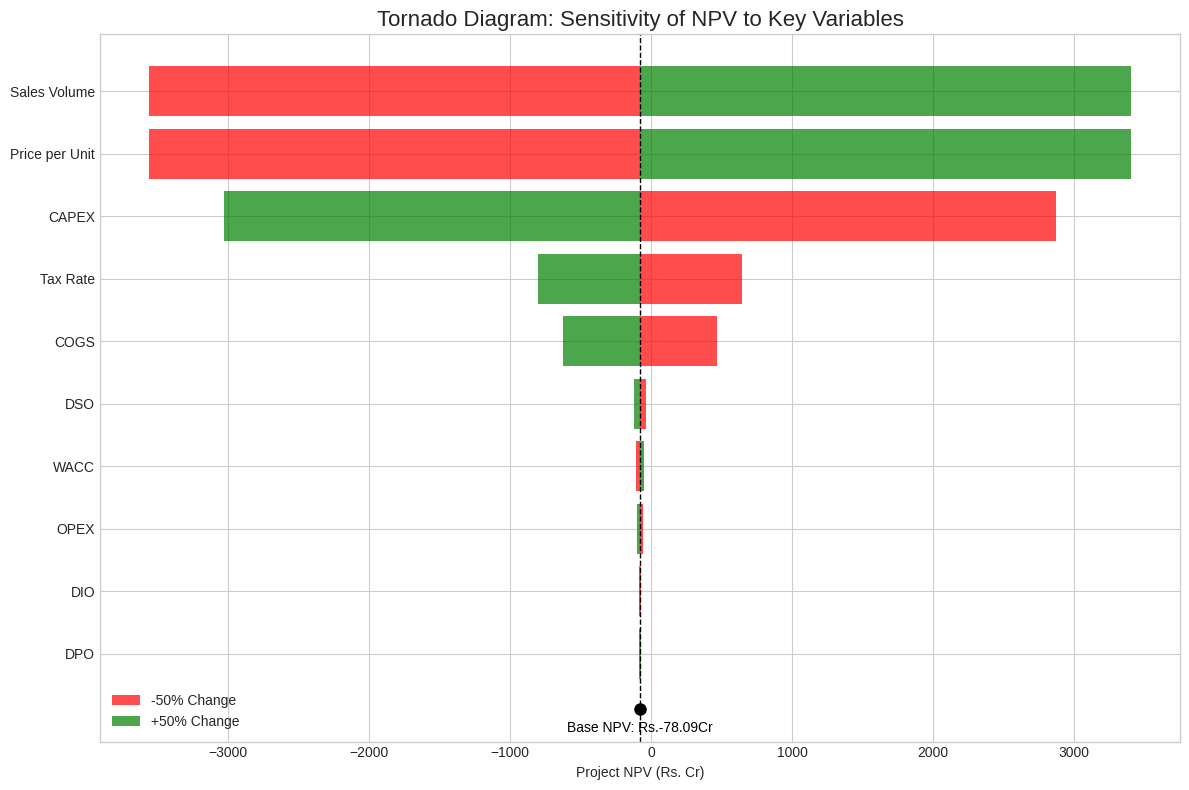

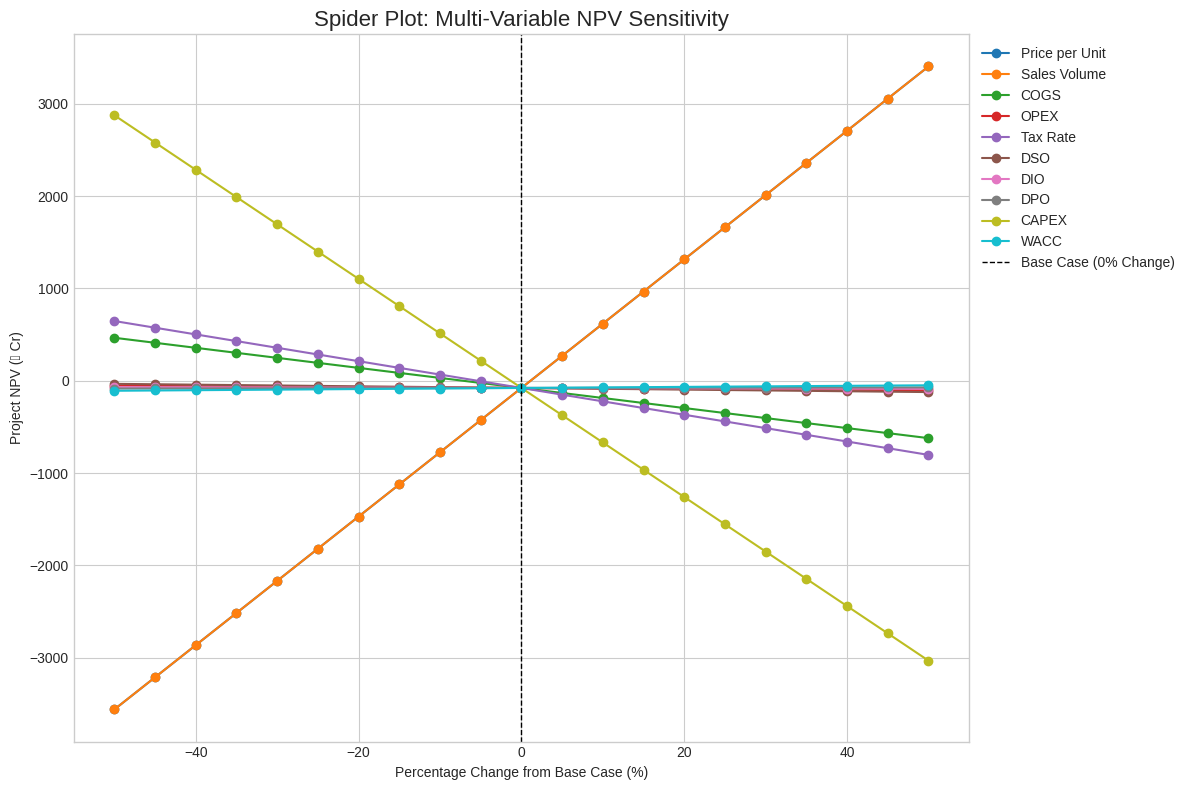

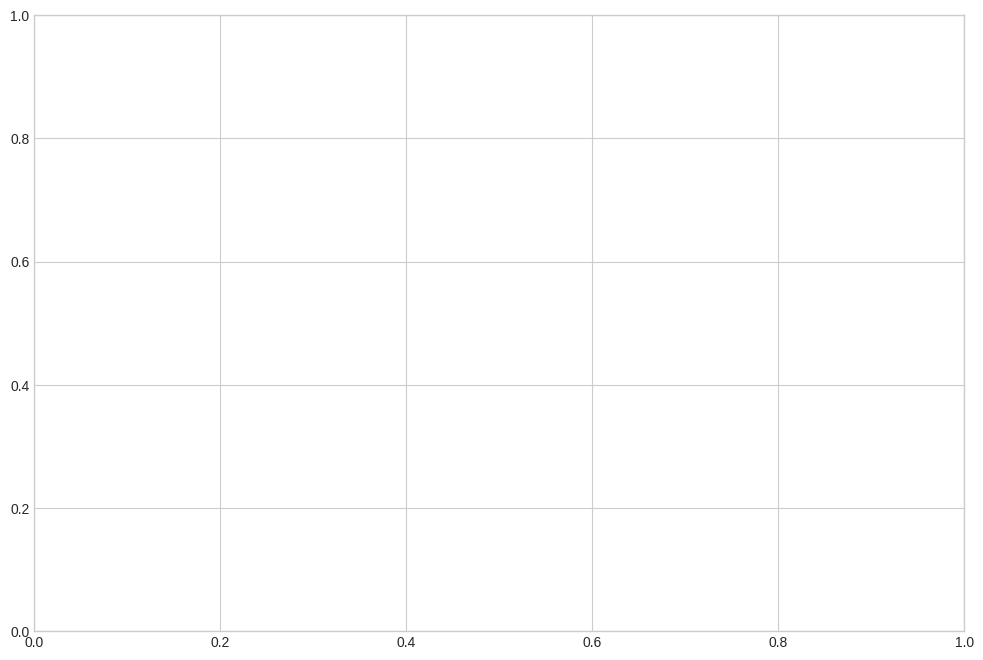

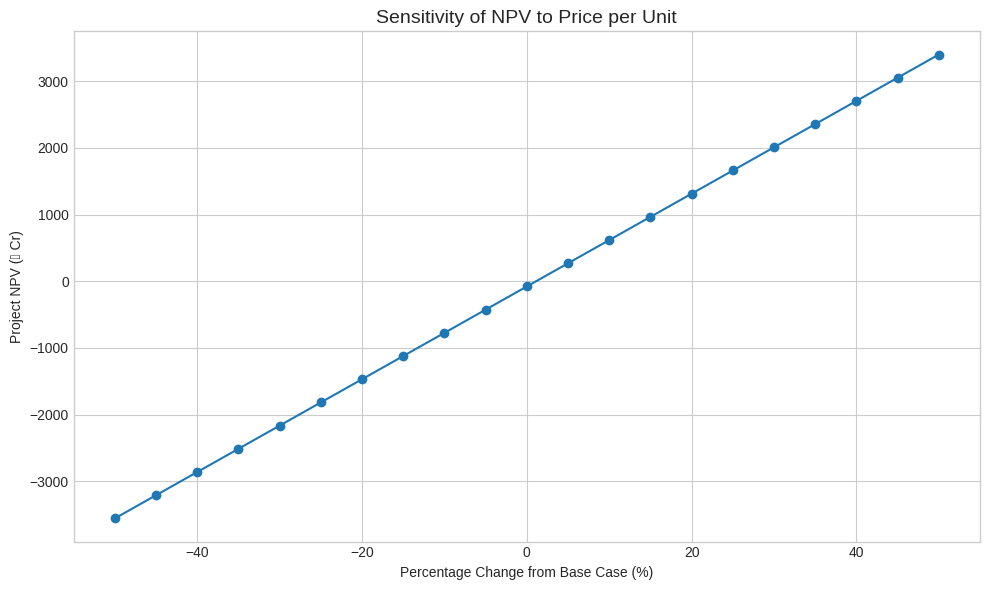

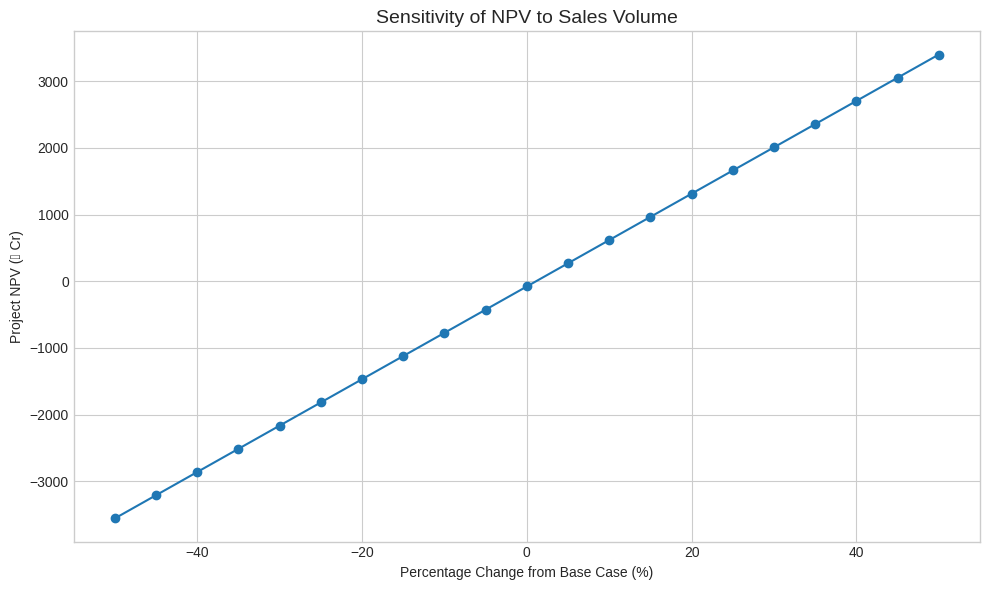

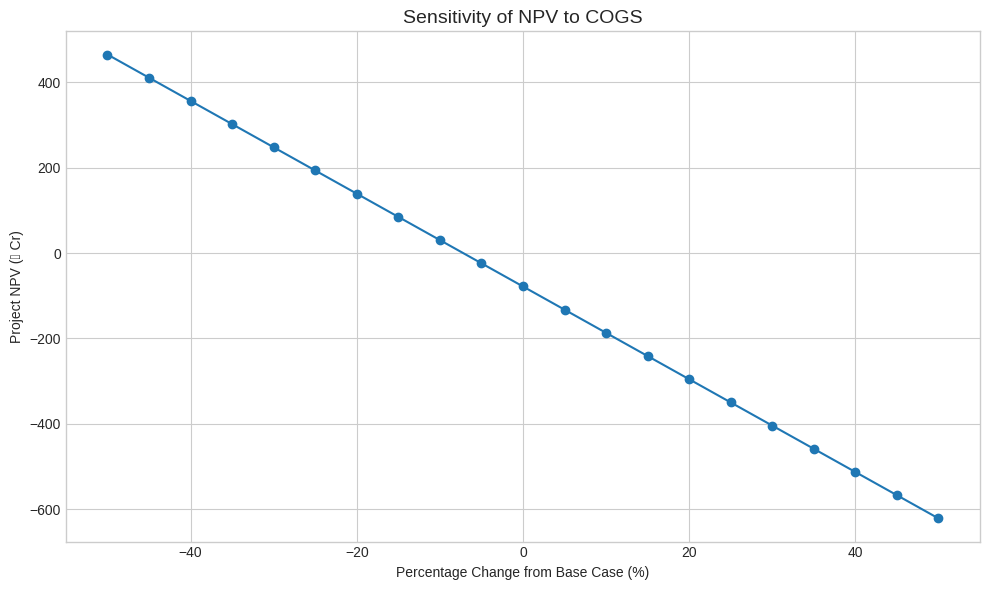

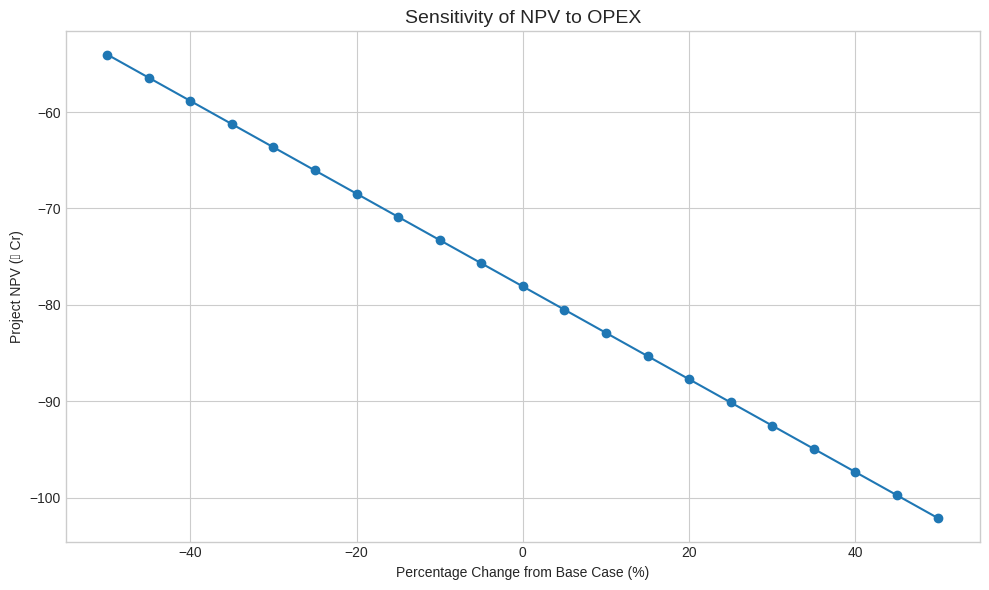

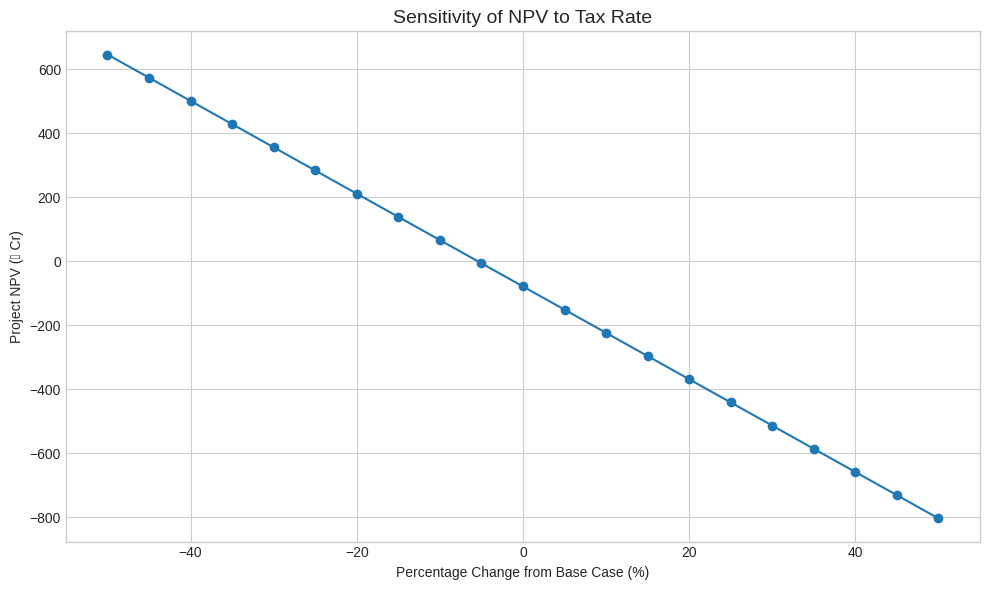

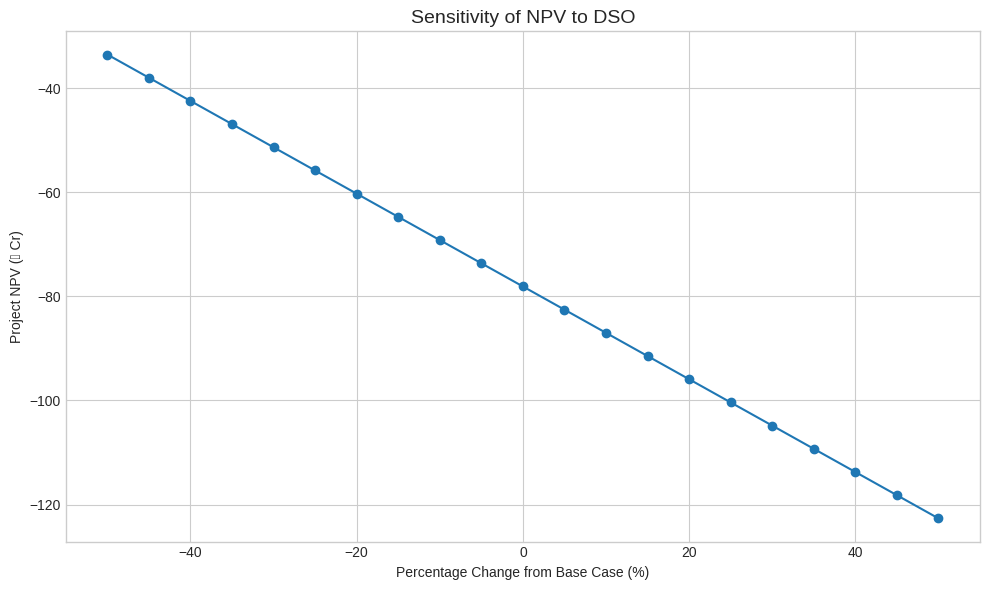

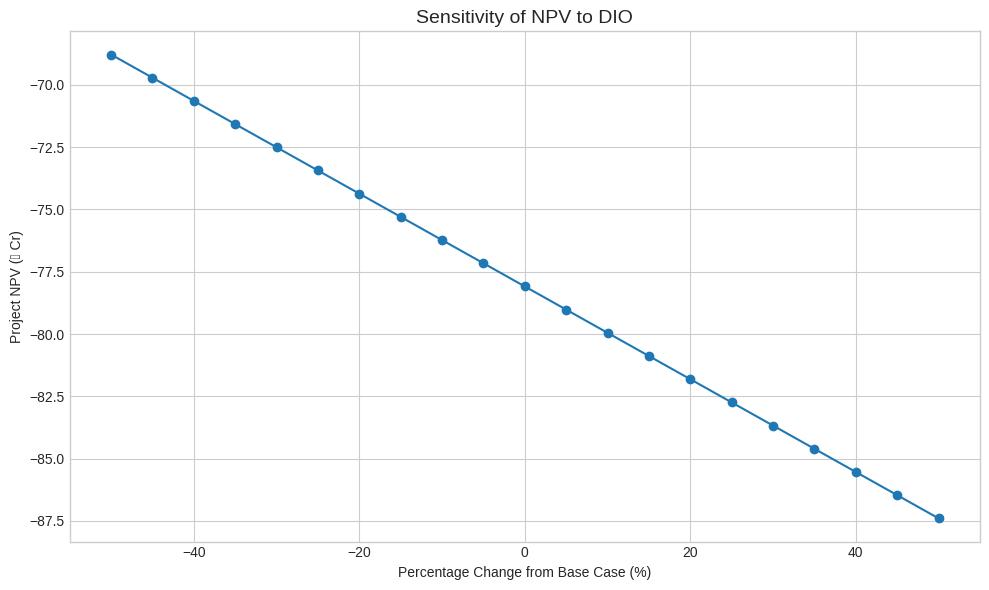

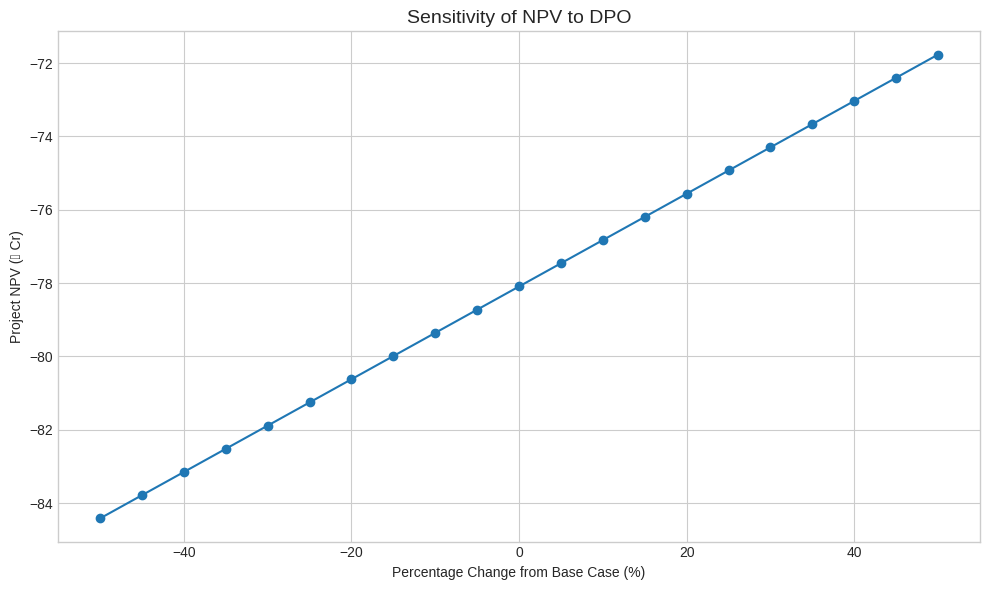

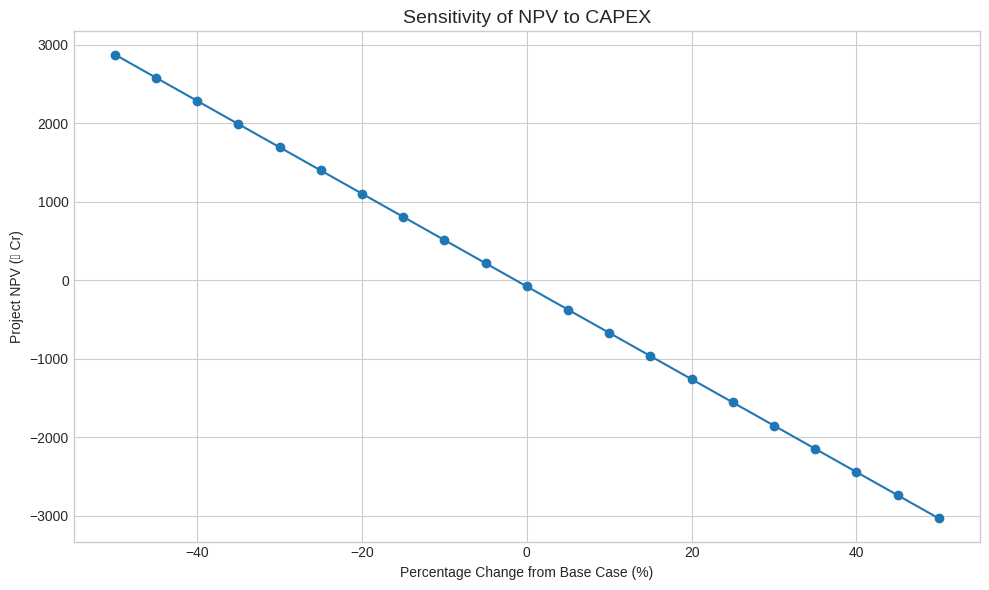

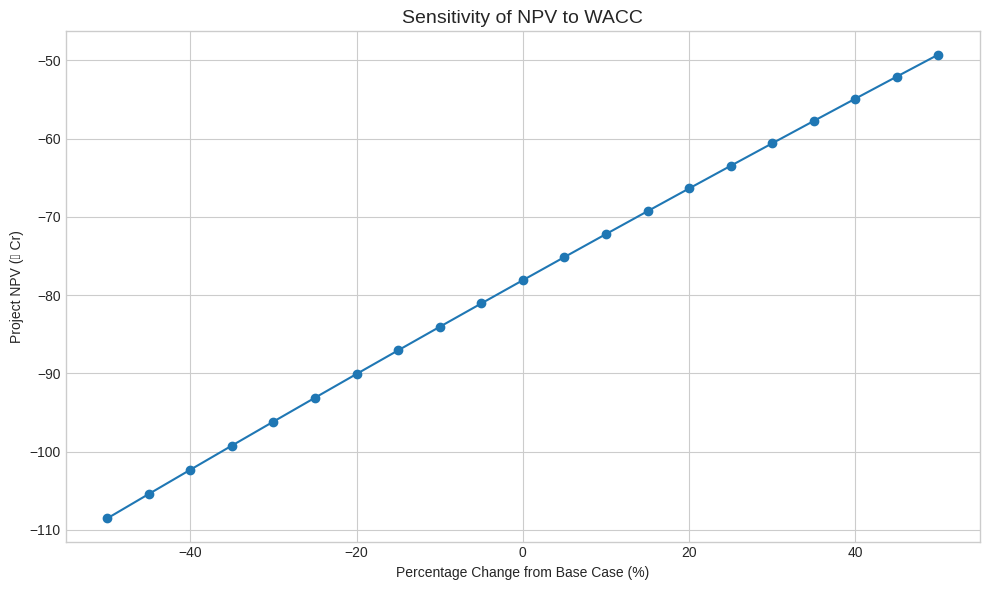

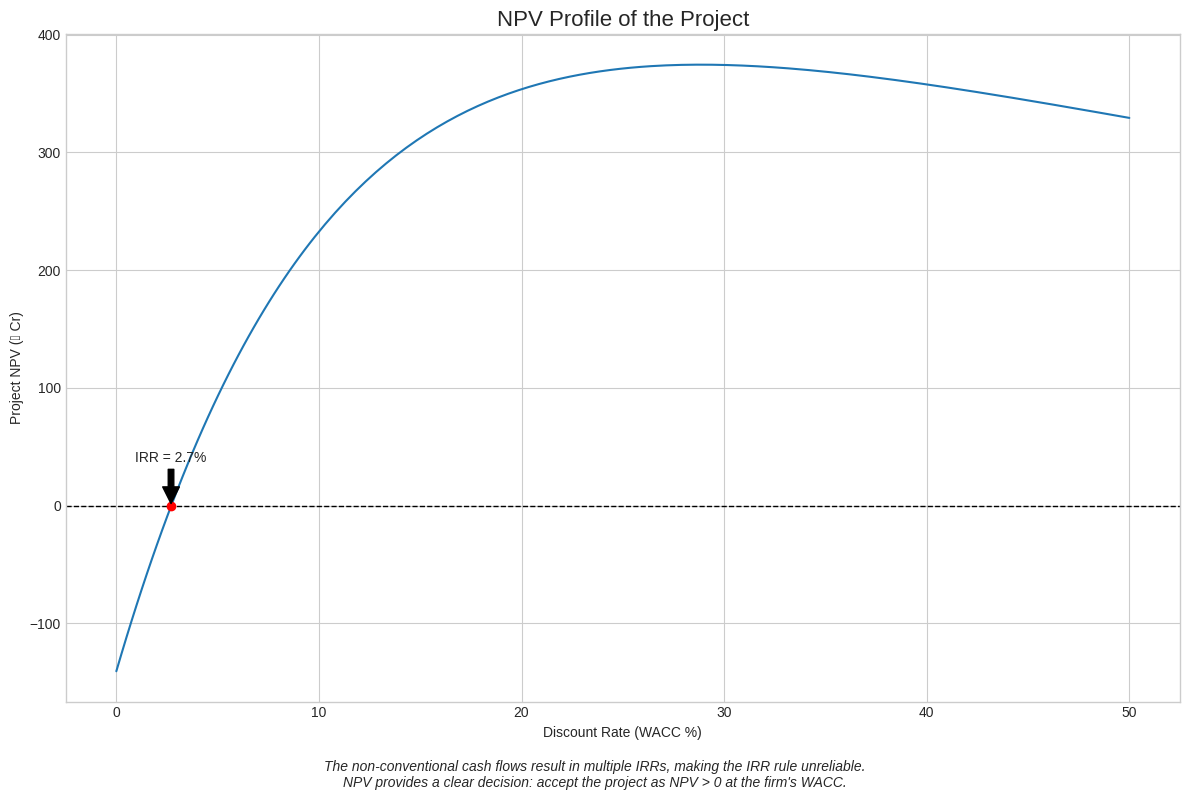

Successfully generated all visualizations.

--- VALUATION & SENSITIVITY ANALYSIS SUMMARY ---
Base Case Project NPV: ₹ -78.09 Cr
Calculated Project IRR(s): 2.7%
Note: Multiple IRRs detected due to non-conventional cash flows.

Top 4 Most Sensitive Variables (from Tornado analysis):
1. Sales Volume (NPV Range: ₹ 6,961.94 Cr)
2. Price per Unit (NPV Range: ₹ 6,961.94 Cr)
3. CAPEX (NPV Range: ₹ 5,905.19 Cr)
4. Tax Rate (NPV Range: ₹ 1,449.56 Cr)


In [13]:
# ==============================================================================
# Helper function to display first row of Base Values sheet
# ==============================================================================
def display_first_row_base_values(file_path):
    """
    Loads the 'Base Values' sheet from the specified Excel file and prints its first row.

    Args:
        file_path (str): The path to the input Excel file.
    """
    try:
        df_base_values = pd.read_excel(file_path, sheet_name='Base Values')

        # Select the first row
        first_row = df_base_values.iloc[0]

        print("\n--- First Row of 'Base Values' Sheet ---")
        print(first_row)

    except FileNotFoundError:
        print(f"Error: Input file not found at {file_path}")
    except KeyError:
        print("Error: 'Base Values' sheet not found in the Excel file.")
    except IndexError:
        print("Error: 'Base Values' sheet is empty.")

# Modify the main execution block to call this function at the beginning
if __name__ == '__main__':
    # Display the first row of the 'Base Values' sheet
    display_first_row_base_values("/content/group3_sensitivity_analysis.xlsx")

    # Step 1: Load base assumptions
    base_assumptions = load_base_assumptions("/content/group3_sensitivity_analysis.xlsx")

    if base_assumptions:
        # Print the loaded input assumptions
        print("\n--- LOADED INPUT ASSUMPTIONS ---")
        for key, value in base_assumptions.items():
            print(f"{key}: {value}")

        # Step 2: Calculate base case NPV, IRR, and pro-forma model
        base_npv, base_irrs, base_model = calculate_npv_irr(base_assumptions)

        # Step 3: Run sensitivity analysis
        sensitivity_data = run_sensitivity_analysis(base_assumptions)

        # Step 4: Generate all output files and display plots
        generate_outputs(base_model, sensitivity_data, base_npv, base_irrs)

        # Step 5: Print summary to console
        print("\n--- VALUATION & SENSITIVITY ANALYSIS SUMMARY ---")
        print(f"Base Case Project NPV: ₹ {base_npv:,.2f} Cr")
        if base_irrs:
            irr_str = ", ".join([f"{irr:.1%}" for irr in base_irrs])
            print(f"Calculated Project IRR(s): {irr_str}")
            print("Note: Multiple IRRs detected due to non-conventional cash flows.")
        else:
            print("No IRR found in the tested range (0% to 50%).")

        print("\nTop 4 Most Sensitive Variables (from Tornado analysis):")
        # Correctly calculate tornado ranges for summary display based on last year's cumulative NPV
        tornado_ranges = {}
        for var_name, df in sensitivity_data.items():
             tornado_ranges[var_name] = abs(df.iloc[-1, -1] - df.iloc[0, -1])

        # Create a DataFrame from the tornado_ranges dictionary
        df_tornado_summary = pd.DataFrame.from_dict(tornado_ranges, orient='index', columns=['NPV Range'])
        df_tornado_summary.sort_values('NPV Range', ascending=False, inplace=True)

        for i, (var, range_val) in enumerate(df_tornado_summary.head(4).itertuples()):
            print(f"{i+1}. {var} (NPV Range: ₹ {range_val:,.2f} Cr)")

In [14]:
# Display the FCFF stream used for NPV and NPV profile calculations
print("\n--- FCFF Stream Used in NPV and NPV Profile Calculations ---")
display(base_model.loc['FCFF'])
display(base_model.loc['Depreciation'])


--- FCFF Stream Used in NPV and NPV Profile Calculations ---


,FCFF
Year 0,-100.000000
Year 1,377.923271
Year 2,410.617781
Year 3,445.994795
Year 4,-1226.985567
Year 5,588.808608
Year 6,625.875123
Year 7,628.862658
Year 8,642.903952
Year 9,-4552.525050


,Depreciation
Year 0,0.000
Year 1,10.000
Year 2,10.314
Year 3,10.685
Year 4,10.966
Year 5,175.966
Year 6,176.676
Year 7,177.486
Year 8,178.396
Year 9,179.406
